Today's topics:
* one integrated worked example, everything from Module 1 on one dataset
* Quiz 3 (in class)
* practice Midterm 1 handout

> Midterm 1: Lecture 18, on paper, closed-notebook. HW6 and Quiz 3 both due/happening today.

# Why Midterm 1 is on paper

Single-day, on paper, closed-notebook -- tests *your* understanding of code, not an AI's.

Three question types (same for Quiz 3 today):
1. **Read code, predict output.**
2. **Write short code by hand** -- full credit for correct logic even with a syntax slip.
3. **Interpret a printed plot** -- no code, judge mean/spread/skew/fit.

Pen or pencil only -- no calculator needed.

# Integrated worked example

Everything from the last two and a half weeks, one realistic workflow. Same 915-alloy steels
dataset: composition (wt%), mechanical properties, `Alloy family` label.

## Dataset: Steel Alloy Compositions and Mechanical Properties

This dataset contains elemental compositions and mechanical properties of 915 steel alloys.

Composition columns (in wt%): `C`, `Si`, `Mn`, `P`, `S`, `Ni`, `Cr`, `Mo`, `Cu`, `V`, `Al`, `N`, `Ceq`, `Nb + Ta`

Target columns: `0.2% Proof Stress (MPa)`, `Tensile Strength (MPa)`, `Elongation (%)`, `Reduction in Area (%)`

The `Alloy code` column contains labels like `A1`, `B3`, etc. We derive `alloy_family` (first letter only)
to get a small set of categorical labels useful for classification tasks (4 families: C, L, M, V, all >150 samples).

In [1]:
import os
import pandas as pd

_file = 'steels.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

# derive alloy family label (first letter of alloy code)
data['Alloy family'] = [c[0] for c in data['Alloy code']]

# set up features (composition columns) and target
x = data.loc[:, ' C':'Nb + Ta']
y = data['Alloy family']
alloy_family = data['Alloy family']

print(f'{len(data)} samples, {x.shape[1]} composition features')
data.head()

915 samples, 14 composition features


,Alloy code,C,Si,Mn,P,S,Ni,Cr,Mo,Cu,...,Al,N,Ceq,Nb + Ta,Temperature (°C),0.2% Proof Stress (MPa),Tensile Strength (MPa),Elongation (%),Reduction in Area (%),Alloy family
0,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,27,342,490,30,71,M
1,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,100,338,454,27,72,M
2,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,200,337,465,23,69,M
3,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,300,346,495,21,70,M
4,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,400,316,489,26,79,M


## Load + inspect (Lecture 8)

In [2]:
data.shape

(915, 21)

In [3]:
data.head()

,Alloy code,C,Si,Mn,P,S,Ni,Cr,Mo,Cu,...,Al,N,Ceq,Nb + Ta,Temperature (°C),0.2% Proof Stress (MPa),Tensile Strength (MPa),Elongation (%),Reduction in Area (%),Alloy family
0,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,27,342,490,30,71,M
1,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,100,338,454,27,72,M
2,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,200,337,465,23,69,M
3,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,300,346,495,21,70,M
4,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,400,316,489,26,79,M


In [4]:
data.columns

Index(['Alloy code', ' C', ' Si', ' Mn', ' P', ' S', ' Ni', ' Cr', ' Mo',
       ' Cu', 'V', ' Al', ' N', 'Ceq', 'Nb + Ta', ' Temperature (°C)',
       ' 0.2% Proof Stress (MPa)', ' Tensile Strength (MPa)',
       ' Elongation (%)', ' Reduction in Area (%)', 'Alloy family'],
      dtype='object')

Same `.shape` idea as arrays back in Lecture 3 -- different object, same attribute.

## Descriptive stats (Lectures 4-5, as Pandas methods)

In [5]:
ts = data[' Tensile Strength (MPa)']
ts.mean(), ts.median(), ts.std()

(np.float64(496.248087431694),
 np.float64(479.0),
 np.float64(239.71064952747744))

In [6]:
ts.describe()

count     915.000000
mean      496.248087
std       239.710650
min       162.000000
25%       413.000000
50%       479.000000
75%       575.000000
max      6661.000000
Name:  Tensile Strength (MPa), dtype: float64

Same mean/median/std as `np.mean` back in Lecture 4 -- a `Series` *is* a NumPy array underneath:

In [7]:
ts.values

array([ 490,  454,  465,  495,  489,  461,  431,  387,  314,  226,  463,
        427,  439,  471,  472,  451,  423,  367,  297,  205,  463,  432,
        459,  473,  464,  451,  424,  378,  297,  221,  502,  467,  482,
        505,  493,  475,  434,  383,  301,  221,  493,  464,  475,  497,
        482,  465,  442,  389,  308,  226,  456,  420,  449,  479,  482,
        471,  435,  375,  304,  211,  453,  419,  449,  485,  474,  468,
        434,  380,  296,  214,  431,  406,  431,  459,  454,  444,  417,
        376,  293,  199,  464,  421,  459,  479,  482,  473,  449,  395,
        317,  213,  462,  418,  457,  479,  482,  479,  441,  393,  299,
        217,  452,  420,  454,  529,  483,  479,  448,  383,  304,  220,
        480,  471,  591,  553,  509,  444,  373,  306,  234,  470,  456,
        572,  540,  500,  431,  371,  302,  229,  470,  453,  564,  546,
        485,  427,  372,  309,  237,  500,  456,  540,  534,  495,  443,
        379,  319,  254,  480,  471,  534,  552,  5

## One histogram (Lecture 9)

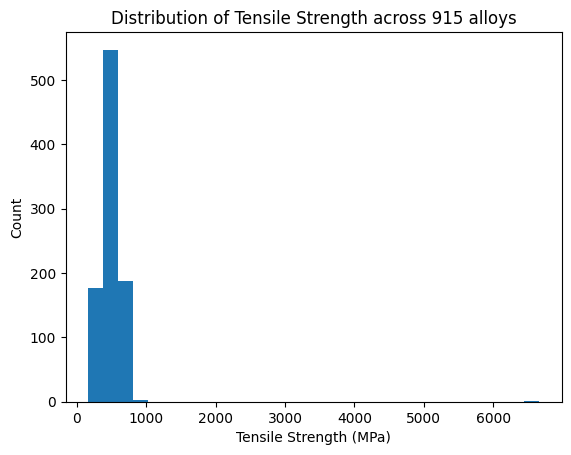

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.hist(ts, bins=30)
ax.set_xlabel('Tensile Strength (MPa)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Tensile Strength across 915 alloys')
plt.show()

*Roughly symmetric? Any outlier-looking tail?* -- midterm question type 3.

## Logical indexing / filtering (Lecture 11)

In [9]:
high_strength = data[data[' Tensile Strength (MPa)'] > 700]
len(high_strength)

50

In [10]:
high_strength['Alloy family'].value_counts()

Alloy family
V    43
C     7
Name: count, dtype: int64

In [11]:
strong_and_ductile = data[(data[' Tensile Strength (MPa)'] > 550) & (data[' Elongation (%)'] > 25)]
len(strong_and_ductile)

42

50 alloys clear 700 MPa (mostly V family); 42 are both strong and ductile -- visibly smaller than
either condition alone. Compound conditions need `&`/`|` with parentheses around each clause.

### [Check your understanding]

* Predict `len(data[data[' Elongation (%)'] > 30])` before running it
* Then run the cell below and check yourself

## Control structures + functions (Lectures 12, 14)

In [12]:
def classify_strength(value):
    if value < 400:
        return 'low'
    elif value < 600:
        return 'medium'
    else:
        return 'high'

In [13]:
labels = []
for v in data[' Tensile Strength (MPa)']:
    labels.append(classify_strength(v))

labels_v2 = data[' Tensile Strength (MPa)'].apply(classify_strength)

labels[:5]

['medium', 'medium', 'medium', 'medium', 'medium']

In [14]:
labels_v2.values[:5]

array(['medium', 'medium', 'medium', 'medium', 'medium'], dtype=object)

Same result two ways: the loop is the mechanics; `.apply()` is the Pandas shortcut. Midterm may
ask for either. (Bucket sizes: 211 low, 519 medium, 185 high.)

## Tying it off (Lectures 1, 4-5, 8, 11, 12 -- five lines, the whole module)

In [15]:
for family in sorted(data['Alloy family'].unique()):
    subset = data[data['Alloy family'] == family]
    print(family, len(subset), round(subset[' Tensile Strength (MPa)'].mean(), 1))

C 385 488.3
L 159 455.9
M 191 426.0
V 180 623.5


Iteration, logical indexing, descriptive stats, string formatting -- five lines. (No `.groupby()`
needed here deliberately -- though you now know that shortcut too.)

### [Check your understanding]

* Rewrite the loop above using `.groupby('Alloy family')` instead
* Confirm you get the same means

# Quiz 3 (in class)

Timed, same format family as the midterm. Scope: cumulative since Quiz 2 -- functions/scope,
consuming objects, plus one cumulative predict-the-output item from earlier weeks. Answer key
posted after class.

# Practice Midterm 1

Leaves with you today -- same format and length as the real thing, drawn from arrays, stats,
Pandas, plotting interpretation, filtering, loops, functions. Not a preview of the real
questions; comfortable in 50 minutes = ready.

HW6 due today (last Module 1 homework). Lecture 17: dedicated review day for the practice
midterm. Midterm 1: Lecture 18, on paper, closed-notebook, pen or pencil only.

After the midterm: Module 2 -- building models of materials behavior, starting with linear
regression.